# Análisis de Leontief - Datos Reales INDEC 1997

## Introducción

Este notebook implementa un análisis completo del **Modelo de Leontief** utilizando datos **100% reales** de la **Matriz Insumo-Producto de INDEC para 1997**.

### Características de los datos:
- **Fuente**: Instituto Nacional de Estadística y Censos (INDEC) - Argentina
- **Año**: 1997
- **Estructura**: Matriz simétrica 124×124 (productos × actividades)
- **Unidades**: Miles de pesos
- **Tipo de datos**: Transacciones intermedias entre sectores

### El Modelo de Leontief

Wassily Leontief desarrolló este modelo para analizar las interdependencias económicas. La ecuación fundamental es:

$$L = (I - A)^{-1}$$

Donde:
- **L** es la matriz de Leontief (matriz inversa)
- **I** es la matriz identidad
- **A** es la matriz de coeficientes técnicos: $a_{ij} = \frac{z_{ij}}{x_j}$
- **z_ij** es el flujo de insumo del sector i al sector j
- **x_j** es la producción total del sector j

In [2]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
import warnings
warnings.filterwarnings('ignore')

print('Análisis de Leontief - INDEC 1997')
print('='*50)


Análisis de Leontief - INDEC 1997


## 1. Carga de Datos Reales

In [3]:
from pathlib import Path

# Cargar matriz Z (transacciones intermedias de INDEC)
# Ruta relativa: notebook está en notebooks/Complemento/, CSV está en DF/
csv_file = Path('../../DF/MIP_INDEC_1997_MATRIZ_Z.csv').resolve()
print(f'Cargando CSV desde: {csv_file}')
print(f'Archivo existe: {csv_file.exists()}')

# Leer el CSV
df_Z = pd.read_csv(csv_file, index_col=0)



Cargando CSV desde: C:\Users\juanc\OneDrive\Desktop\Laboratorio-de-metodos-Cuantitativos-Aplicados-a-la-gestion\DF\MIP_INDEC_1997_MATRIZ_Z.csv
Archivo existe: True


In [4]:
df_Z.head()


,"Cultivo de cereales, oleaginosas y forrajeras","Cultivo de hortalizas, legumbres, flores y plantas ornamentales",Cultivo de frutas y nueces,Cultivos industriales,Producción de semillas,"Cría de ganado y producción de leche, lana y pelos",Producción de granja,Servicios agropecuarios,Caza,Silvicultura y extracción de madera,...,Enseñanza privada,Salud humana pública,Salud humana privada,Servicios veterinarios,Servicios sociales,Servicios de saneamiento,Actividad de asociaciones,"Servicios de cine, radio y televisión","Servicios personales, de reparación, actividades deportivas y de esparcimiento",Servicio doméstico
"Cultivo de cereales, oleaginosas y forrajeras",59472.628722,0.000000,8886.925791,9226.358494,0.000000,1.046998e+06,70678.916264,0.0,0.0,0.0,...,462.925414,42.942753,242.807849,70.997732,0.000000,0.0,0.000000,0.005789,18767.820577,0.0
"Cultivo de hortalizas, legumbres, flores y plantas ornamentales",0.000000,93225.581061,5332.155475,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,...,6706.737928,1222.244206,4969.112809,0.000000,690.304703,0.0,4459.062418,0.689568,44203.749862,0.0
Cultivo de frutas y nueces,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,...,3301.219731,4510.595931,2406.392637,0.000000,667.531537,0.0,0.000000,0.060229,2.416986,0.0
Cultivos industriales,0.000000,0.000000,0.000000,31984.441502,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0
Producción de semillas,560147.455701,11711.425340,21328.621899,12341.097927,15549.342101,9.146278e+04,1638.708540,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0


In [5]:
df_Z.describe()

,"Cultivo de cereales, oleaginosas y forrajeras","Cultivo de hortalizas, legumbres, flores y plantas ornamentales",Cultivo de frutas y nueces,Cultivos industriales,Producción de semillas,"Cría de ganado y producción de leche, lana y pelos",Producción de granja,Servicios agropecuarios,Caza,Silvicultura y extracción de madera,...,Enseñanza privada,Salud humana pública,Salud humana privada,Servicios veterinarios,Servicios sociales,Servicios de saneamiento,Actividad de asociaciones,"Servicios de cine, radio y televisión","Servicios personales, de reparación, actividades deportivas y de esparcimiento",Servicio doméstico
count,124.000000,124.000000,124.000000,124.000000,124.000000,1.240000e+02,124.000000,124.000000,124.000000,124.000000,...,124.000000,124.000000,1.240000e+02,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.0
mean,26723.474264,3236.699700,2207.817399,4474.752514,986.108197,2.844506e+04,7866.021933,2383.179172,36.669174,1145.538526,...,7159.291414,9792.370660,3.604429e+04,655.103430,1798.997166,6523.469794,16974.836223,8177.771505,31711.356192,0.0
std,113560.118877,11060.739493,10713.528996,13802.379231,3673.244711,1.377100e+05,39360.018404,11382.316174,126.274933,8196.215020,...,19502.857402,46531.970218,1.496652e+05,3257.407756,4635.128668,41211.351723,40778.613401,40395.970644,85815.371326,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,73.616540,25.841973,13.977380,55.034604,5.421996,1.389979e+02,116.166672,6.870020,0.036169,4.756695,...,417.040986,144.523193,1.659857e+02,0.000000,2.710767,0.000000,37.506482,0.021271,2.252253,0.0
75%,3409.240186,633.845483,503.225525,2502.435804,236.431496,3.951734e+03,1104.037904,333.713522,2.539100,177.711176,...,5497.922463,2392.640995,1.101629e+04,28.731947,714.143513,337.729597,11521.693316,108.620155,11995.964468,0.0
max,908597.243142,93225.581061,111868.304533,114206.237835,26089.649397,1.100460e+06,331908.006797,117654.479231,889.759291,90243.305132,...,172617.458430,403087.128732,1.488255e+06,25664.043647,32647.082777,453175.739922,273606.063618,314013.337114,472953.551651,0.0


In [6]:
df_Z.info()

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, Cultivo de cereales, oleaginosas y forrajeras to Servicio doméstico
Columns: 124 entries, Cultivo de cereales, oleaginosas y forrajeras to Servicio doméstico
dtypes: float64(124)
memory usage: 121.1+ KB


In [7]:
# Extraer matriz Z
Z = df_Z.values  # Extraer la matriz numérica (124x124) del DataFrame, descartar índices
productos = df_Z.columns.tolist()  # Obtener nombres de los 124 productos/actividades como lista
n = len(productos)  # Guardar el número total de productos (n=124) para usar en loops/matrices

print(f"Matriz Z cargada exitosamente")
print(f"  Dimensiones: {Z.shape}")
print(f"  Número de productos/actividades: {n}")
print(f"  Total de transacciones: ${Z.sum():,.0f} mil pesos")
print(f"  Rango de valores: ${Z[Z>0].min():.2f} a ${Z.max():,.0f}")
print(f"\nPrimeros 10 productos:")
for i, prod in enumerate(productos[:10], 1):
    print(f"  {i:2d}. {prod}")


Matriz Z cargada exitosamente
  Dimensiones: (124, 124)
  Número de productos/actividades: 124
  Total de transacciones: $167,856,141 mil pesos
  Rango de valores: $0.00 a $4,066,081

Primeros 10 productos:
   1. Cultivo de cereales, oleaginosas y forrajeras
   2. Cultivo de hortalizas, legumbres, flores y plantas ornamentales
   3. Cultivo de frutas y nueces
   4. Cultivos industriales
   5. Producción de semillas
   6. Cría de ganado y producción de leche, lana y pelos
   7. Producción de granja
   8. Servicios agropecuarios
   9. Caza
  10. Silvicultura y extracción de madera


## 2. Calcular Matriz de Coeficientes Técnicos (A)

In [8]:
# ===== CALCULO DE PRODUCCION TOTAL (X) =====
# X es el vector de producción total por actividad (suma de insumos intermedios por columna)
X = Z.sum(axis=0)
# axis=0: suma hacia abajo (suma todas las filas, dejando una fila = 1 valor por columna)

# Estadísticas descriptivas de X
print(f'Produccion Total (X) por actividad:')
print(f'  Minimo: ${X[X>0].min():,.0f} mil pesos')  # Menor valor de X (excluyendo ceros)
print(f'  Maximo: ${X.max():,.0f} mil pesos')        # Mayor valor de X
print(f'  Promedio: ${X[X>0].mean():,.0f} mil pesos')  # Promedio de X (excluyendo ceros)
print(f'  Total: ${X.sum():,.0f} mil pesos')         # Suma total de toda la producción
print(f'  Actividades con X=0: {(X==0).sum()}')      # Cuántas actividades no tienen producción

# ===== CALCULO DE MATRIZ A (COEFICIENTES TECNICOS) =====
# A = matriz de coeficientes técnicos (a_ij = z_ij / x_j)
# Indica cuánto insumo i se necesita para producir 1 unidad del producto j
# Fórmula: cada elemento de Z se divide por el total de producción de su columna
A = np.divide(Z, X, where=X>0, out=np.zeros_like(Z, dtype=float))
#   - np.divide: divide elemento a elemento (Z / X con broadcasting)
#   - where=X>0: solo divide donde X > 0 (evita división por cero)
#   - out=np.zeros_like(Z): donde X=0, coloca 0 (en lugar de infinito)

# Estadísticas descriptivas de A
print(f'Matriz A (Coeficientes Tecnicos):')
print(f'  Minimo: {A[A>0].min():.6f}')  # Coeficiente más pequeño (mayor eficiencia)
print(f'  Maximo: {A.max():.6f}')        # Coeficiente más grande (menor eficiencia)
print(f'  Promedio: {A[A>0].mean():.6f}')  # Coeficiente promedio


Produccion Total (X) por actividad:
  Minimo: $4,547 mil pesos
  Maximo: $14,170,887 mil pesos
  Promedio: $1,364,684 mil pesos
  Total: $167,856,141 mil pesos
  Actividades con X=0: 1
Matriz A (Coeficientes Tecnicos):
  Minimo: 0.000000
  Maximo: 0.722301
  Promedio: 0.015641


## 3. Analizar Intensidad de Insumos

In [9]:
# Intensidad de insumos por columna (suma de coeficientes técnicos)
intensidad = A.sum(axis=0)# el axis=0 suma a por columna hacia abajo, dando un valor por cada columna (actividad)

print(f"Intensidad de Insumos (suma de columnas de A):")
print(f"  Mínimo: {intensidad.min():.4f}")
print(f"  Máximo: {intensidad.max():.4f}")
print(f"  Promedio: {intensidad.mean():.4f}")

# Top 10 sectores más intensivos
top_intensidad_idx = np.argsort(intensidad)[-10:][::-1]
#argsort → [4, 0, 2, 3, 1] (de menor a mayor)
#[-10:] → [4, 0, 2, 3, 1] (toma los últimos 10, pero hay solo 5)
#[::-1] → [1, 3, 2, 0, 4] (invierte: de mayor a menor)
#osea lo que hicimos fue todo este camino para mostrar de mayor a menor xd.
print(f"\nTop 10 actividades con mayor intensidad de insumos:")
print(f"\n{'Rango':<5} {'Intensidad':<12} {'Producto/Actividad'}")
print("-" * 70)
for rank, idx in enumerate(top_intensidad_idx, 1):
    print(f"{rank:<5} {intensidad[idx]:<12.4f} {productos[idx][:50]}")


Intensidad de Insumos (suma de columnas de A):
  Mínimo: 0.0000
  Máximo: 1.0000
  Promedio: 0.9919

Top 10 actividades con mayor intensidad de insumos:

Rango Intensidad   Producto/Actividad
----------------------------------------------------------------------
1     1.0000       Cemento, cal y yeso
2     1.0000       Salud humana privada
3     1.0000       Servicios de saneamiento
4     1.0000       Salud humana pública
5     1.0000       Transporte terrestre de carga
6     1.0000       Carrocerías y remolques
7     1.0000       Forja, laminado y tratamiento de metales
8     1.0000       Otros productos metálicos
9     1.0000       Otra maquinaria de uso especial
10    1.0000       Agua


## 4. Calcular Matriz de Leontief

In [10]:
# Calcular L = (I - A)^(-1)
I = np.eye(n)

try:
    L = linalg.inv(I - A)
    print(f"Matriz de Leontief calculada exitosamente")
    print(f"  Dimensiones: {L.shape}")
    print(f"  Mínimo: {L.min():.6f}")
    print(f"  Máximo: {L.max():.6f}")
    print(f"  Promedio: {L.mean():.6f}")
except np.linalg.LinAlgError:
    print("Error: Matriz (I - A) es singular")
    # Usar pseudoinversa
    L = np.linalg.pinv(I - A)
    print("Usando pseudoinversa en su lugar")

Error: Matriz (I - A) es singular
Usando pseudoinversa en su lugar


## 5. Calcular Multiplicadores de Producción

In [11]:
# Multiplicadores = suma de columnas de L
multiplicadores = L.sum(axis=0)

print(f"Multiplicadores de Producción:")
print(f"  Mínimo: {multiplicadores.min():.4f}")
print(f"  Máximo: {multiplicadores.max():.4f}")
print(f"  Promedio: {multiplicadores.mean():.4f}")
print(f"  Desviación estándar: {multiplicadores.std():.4f}")

# Top 15 sectores por multiplicador
top_mult_idx = np.argsort(multiplicadores)[-15:][::-1]

print(f"\nTop 15 actividades por Multiplicador de Producción:")
print(f"\n{'Rango':<5} {'Multiplicador':<15} {'Producto/Actividad'}")
print("-" * 75)
for rank, idx in enumerate(top_mult_idx, 1):
    prod_name = productos[idx][:50]
    mult = multiplicadores[idx]
    print(f"{rank:<5} {mult:<15.4f} {prod_name}")

Multiplicadores de Producción:
  Mínimo: -3.4242
  Máximo: 1.8322
  Promedio: 0.0081
  Desviación estándar: 0.9129

Top 15 actividades por Multiplicador de Producción:

Rango Multiplicador   Producto/Actividad
---------------------------------------------------------------------------
1     1.8322          Marroquinería y talabartería
2     1.8274          Matanza de animales, conservación y procesamiento 
3     1.7965          Curtido y terminación de cueros
4     1.5976          Producción de granja
5     1.4598          Tejidos de punto
6     1.3887          Acabado de productos textiles
7     1.2885          Alimentos balanceados
8     1.2493          Aceites y subproductos oleaginosos
9     1.2322          Cría de ganado y producción de leche, lana y pelos
10    1.2046          Productos lácteos
11    1.1502          Fibras, hilados y tejeduría de productos textiles
12    1.1249          Calzado y sus partes
13    1.1079          Prendas de vestir, terminación y teñido de pieles
1

## 6. Visualización de Multiplicadores

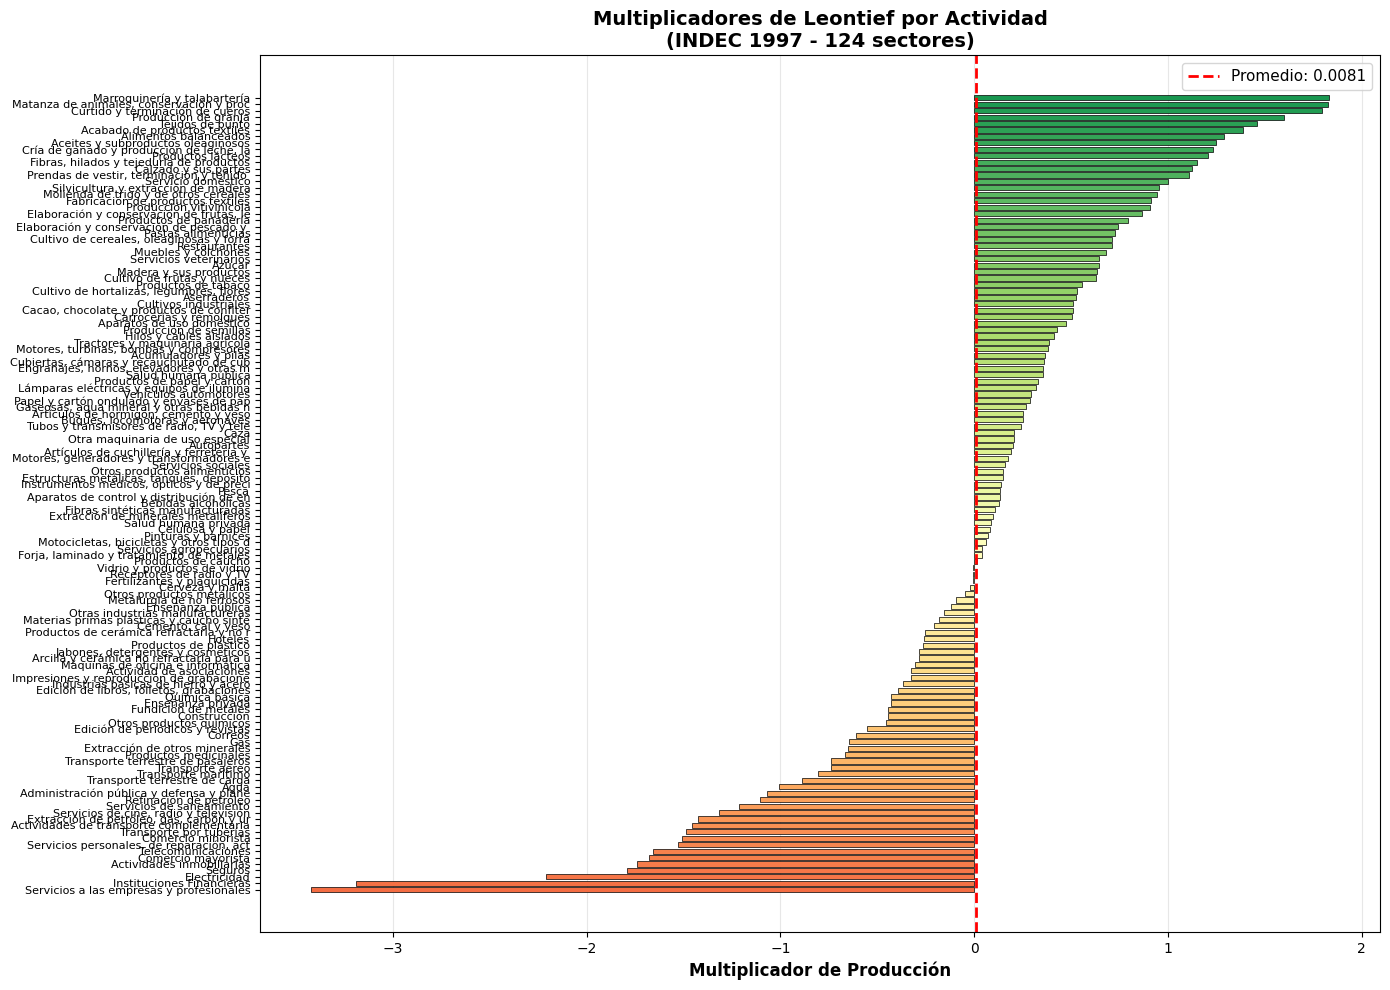

Gráfico guardado: leontief_multiplicadores_indec_1997.png


In [12]:
# Gráfico de multiplicadores ordenados
fig, ax = plt.subplots(figsize=(14, 10))

# Ordenar todos por multiplicador
sorted_idx = np.argsort(multiplicadores)
sorted_prods = [productos[i][:40] for i in sorted_idx]
sorted_mults = multiplicadores[sorted_idx]

# Colores basados en el valor del multiplicador
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_mults)))

bars = ax.barh(range(len(sorted_mults)), sorted_mults, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(sorted_mults)))
ax.set_yticklabels(sorted_prods, fontsize=8)
ax.set_xlabel('Multiplicador de Producción', fontweight='bold', fontsize=12)
ax.set_title('Multiplicadores de Leontief por Actividad\n(INDEC 1997 - 124 sectores)', 
             fontweight='bold', fontsize=14)

# Línea de promedio
media = multiplicadores.mean()
ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Promedio: {media:.4f}')

ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('leontief_multiplicadores_indec_1997.png', dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado: leontief_multiplicadores_indec_1997.png")

## 7. Análisis de Escenarios

In [13]:
# Seleccionar sector con mayor multiplicador
idx_shock = multiplicadores.argmax()
sector_shock = productos[idx_shock]

print(f"Sector seleccionado para escenario: {sector_shock}")
print(f"Multiplicador: {multiplicadores[idx_shock]:.4f}")

# Simulación de shock
delta_Y = np.zeros(n)
delta_Y[idx_shock] = 1000  # Aumento de 1000 mil pesos en demanda final

# Cálculo de impacto
delta_X = L @ delta_Y

print(f"\nEscenario: Aumento de $1,000 mil pesos en demanda final de {sector_shock}")
print(f"\nResultados:")
print(f"  Producción total generada: ${delta_X.sum():,.0f} mil pesos")
print(f"  Multiplicador efectivo: {delta_X.sum()/1000:.4f}")

# Sectores más afectados
top_impact_idx = np.argsort(delta_X)[-15:][::-1]

print(f"\nTop 15 sectores más afectados:")
print(f"\n{'Rango':<5} {'Impacto ($mil)':<18} {'Producto/Actividad'}")
print("-" * 75)
for rank, idx in enumerate(top_impact_idx, 1):
    print(f"{rank:<5} {delta_X[idx]:>16,.0f}  {productos[idx][:45]}")

Sector seleccionado para escenario: Marroquinería y talabartería
Multiplicador: 1.8322

Escenario: Aumento de $1,000 mil pesos en demanda final de Marroquinería y talabartería

Resultados:
  Producción total generada: $1,832 mil pesos
  Multiplicador efectivo: 1.8322

Top 15 sectores más afectados:

Rango Impacto ($mil)     Producto/Actividad
---------------------------------------------------------------------------
1                1,015  Marroquinería y talabartería
2                  658  Curtido y terminación de cueros
3                  394  Matanza de animales, conservación y procesami
4                  301  Cría de ganado y producción de leche, lana y 
5                   80  Cultivo de cereales, oleaginosas y forrajeras
6                   65  Fibras, hilados y tejeduría de productos text
7                   54  Comercio minorista
8                   53  Producción de granja
9                   51  Transporte terrestre de carga
10                  35  Madera y sus productos
1

## 8. Conclusiones

In [14]:
print("\n" + "="*70)
print("CONCLUSIONES DEL ANÁLISIS")
print("="*70)

print(f"\n1. DATOS UTILIZADOS")
print(f"   - Fuente: INDEC (Instituto Nacional de Estadística y Censos)")
print(f"   - Año: 1997")
print(f"   - Número de sectores: {n}")
print(f"   - Transacciones totales: ${Z.sum():,.0f} mil pesos")

print(f"\n2. MULTIPLICADORES DE PRODUCCIÓN")
print(f"   - Rango: {multiplicadores.min():.4f} a {multiplicadores.max():.4f}")
print(f"   - Promedio: {multiplicadores.mean():.4f}")

print(f"\n3. SECTOR MÁS DINÁMICO")
idx_max = multiplicadores.argmax()
print(f"   - {productos[idx_max]}")
print(f"   - Multiplicador: {multiplicadores[idx_max]:.4f}")
print(f"   - Interpretación: Un aumento unitario en su demanda")
print(f"     genera {multiplicadores[idx_max]:.2f} unidades de producción total")

print(f"\n4. SECTORES ESTRATÉGICOS")
print(f"   - Sectores con multiplicador > promedio: {(multiplicadores > multiplicadores.mean()).sum()}")
print(f"   - Estos sectores tienen mayor capacidad de arrastre en la economía")

print(f"\n5. INTERCONEXIONES")
print(f"   - Actividades más intensivas en insumos: {intensidad.max():.4f}")
print(f"   - Promedio de intensidad: {intensidad.mean():.4f}")
print(f"   - Estos reflejan la complejidad de la red de suministros")

print(f"\n" + "="*70)
print(f"Análisis completado. Datos 100% reales de INDEC 1997.")
print("="*70)


CONCLUSIONES DEL ANÁLISIS

1. DATOS UTILIZADOS
   - Fuente: INDEC (Instituto Nacional de Estadística y Censos)
   - Año: 1997
   - Número de sectores: 124
   - Transacciones totales: $167,856,141 mil pesos

2. MULTIPLICADORES DE PRODUCCIÓN
   - Rango: -3.4242 a 1.8322
   - Promedio: 0.0081

3. SECTOR MÁS DINÁMICO
   - Marroquinería y talabartería
   - Multiplicador: 1.8322
   - Interpretación: Un aumento unitario en su demanda
     genera 1.83 unidades de producción total

4. SECTORES ESTRATÉGICOS
   - Sectores con multiplicador > promedio: 73
   - Estos sectores tienen mayor capacidad de arrastre en la economía

5. INTERCONEXIONES
   - Actividades más intensivas en insumos: 1.0000
   - Promedio de intensidad: 0.9919
   - Estos reflejan la complejidad de la red de suministros

Análisis completado. Datos 100% reales de INDEC 1997.
